# 🔬 Breast Cancer Diagnosis using K-Nearest Neighbors (KNN)

## Project Overview
This project uses the **K-Nearest Neighbors (KNN)** algorithm to classify breast tumors 
as **Malignant (cancerous)** or **Benign (non-cancerous)** based on measurements taken 
from digitized images of breast mass cell nuclei.

## Dataset
We use the **Breast Cancer Wisconsin (Diagnostic) Dataset**, a real-world dataset 
built into scikit-learn, originally collected at the University of Wisconsin Hospitals.

## What this project covers
- Exploratory Data Analysis (EDA)
- Feature Scaling (why it's critical for KNN)
- Train-Test Split
- Building a baseline KNN model
- **Cross-Validation** to find the optimal value of K
- Model Evaluation (accuracy, confusion matrix, classification report)
- **Decision Surface Visualization** to see how KNN separates classes
- Saving the final trained model

## Why KNN?
KNN is a distance-based, instance-based learning algorithm. It classifies a new data 
point based on the majority class among its 'K' nearest neighbors in the feature space. 
It's simple, intuitive, and a great algorithm to understand core ML concepts like 
distance metrics, decision boundaries, and the bias-variance tradeoff (via K).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA

sns.set_style("whitegrid")
%matplotlib inline

print("All libraries imported successfully!")

All libraries imported successfully!


In [5]:
# Load the dataset
data = load_breast_cancer()

# Convert to a pandas DataFrame for easier exploration
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target  # 0 = malignant, 1 = benign

print("Shape of dataset:", df.shape)
print("\nTarget classes:", data.target_names)
print("\nFirst 5 rows:")
df.sample(5)

Shape of dataset: (569, 31)

Target classes: ['malignant' 'benign']

First 5 rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
521,24.630,21.60,165.50,1841.0,0.10300,0.21060,0.231000,0.147100,0.1991,0.06739,...,26.93,205.70,2642.0,0.1342,0.41880,0.46580,0.24750,0.3157,0.09671,0
467,9.668,18.10,61.06,286.3,0.08311,0.05428,0.014790,0.005769,0.1680,0.06412,...,24.62,71.11,380.2,0.1388,0.12550,0.06409,0.02500,0.3057,0.07875,1
234,9.567,15.91,60.21,279.6,0.08464,0.04087,0.016520,0.016670,0.1551,0.06403,...,19.16,65.74,335.9,0.1504,0.09515,0.07161,0.07222,0.2757,0.08178,1
426,10.480,14.98,67.49,333.6,0.09816,0.10130,0.063350,0.022180,0.1925,0.06915,...,21.57,81.41,440.4,0.1327,0.29960,0.29390,0.09310,0.3020,0.09646,1
424,9.742,19.12,61.93,289.7,0.10750,0.08333,0.008934,0.019670,0.2538,0.07029,...,23.17,71.79,380.9,0.1398,0.13520,0.02085,0.04589,0.3196,0.08009,1


## Understanding the Dataset

- **569 samples**, **30 numeric features** (radius, texture, perimeter, area, smoothness, etc.)
- **Target**: 0 = Malignant, 1 = Benign
- Each feature is a real-valued measurement computed from a digitized image of a cell nucleus.

Let's check for missing values, class balance, and basic statistics before touching the model.

In [6]:
# Check for missing values
print("Missing values per column:\n", df.isnull().sum().sum())

# Class distribution
print("\nClass distribution:")
print(df['target'].value_counts())
print("\nAs percentage:")
print(df['target'].value_counts(normalize=True) * 100)

# Basic statistics
df.describe()

Missing values per column:
 0

Class distribution:
target
1    357
0    212
Name: count, dtype: int64

As percentage:
target
1    62.741652
0    37.258348
Name: proportion, dtype: float64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


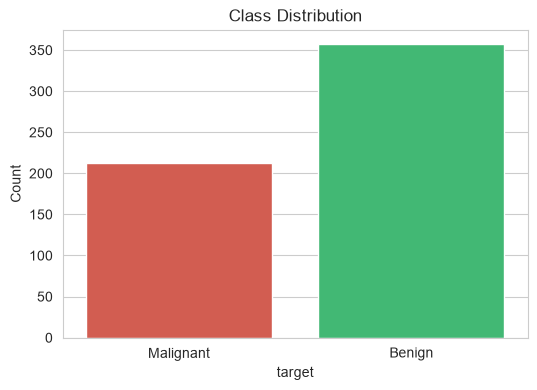

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df, hue='target', palette=['#e74c3c', '#2ecc71'], legend=False)
plt.xticks([0,1], ['Malignant', 'Benign'])
plt.title('Class Distribution')
plt.ylabel('Count')
plt.show()

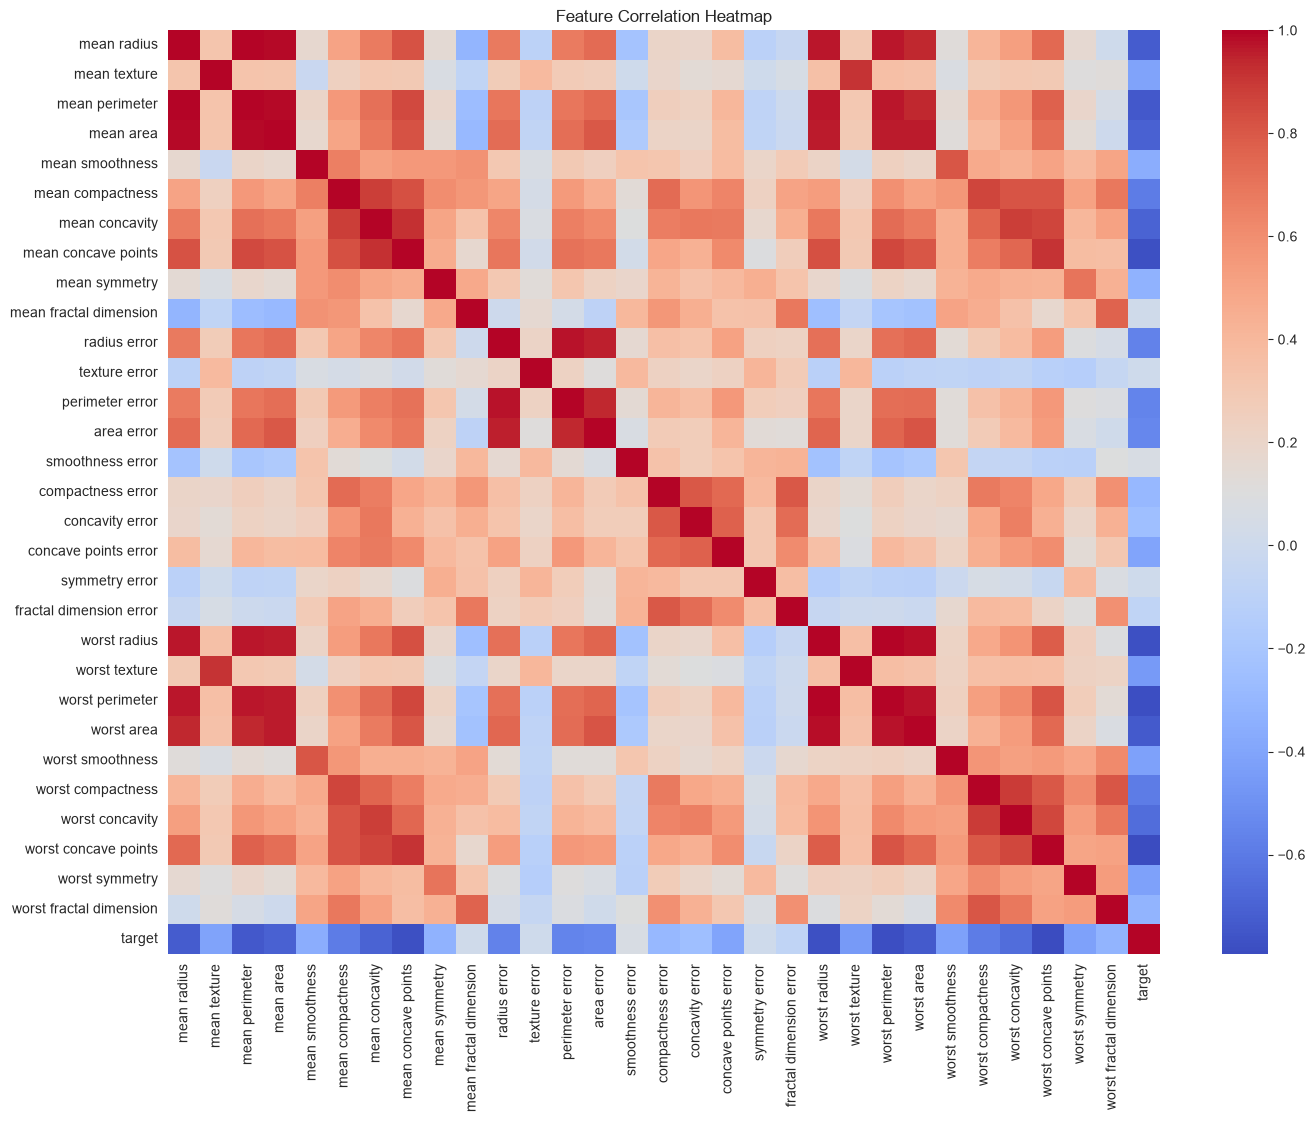

In [11]:
plt.figure(figsize=(16,12))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title('Feature Correlation Heatmap')
plt.show()

## Why Feature Scaling is Critical for KNN

KNN classifies points based on **distance** (usually Euclidean distance) to their 
nearest neighbors. 

Look at our features: `mean area` can be in the range of 500–2500, while 
`mean smoothness` is between 0.05–0.15. 

If we don't scale these, KNN will treat `mean area` as far more "important" simply 
because its numbers are bigger — not because it's actually more predictive. 
Distance calculations get dominated by large-scale features.

**Solution:** Standardize all features to the same scale (mean = 0, std = 1) using 
`StandardScaler`, so every feature contributes fairly to the distance calculation.

Let's prove this visually first.

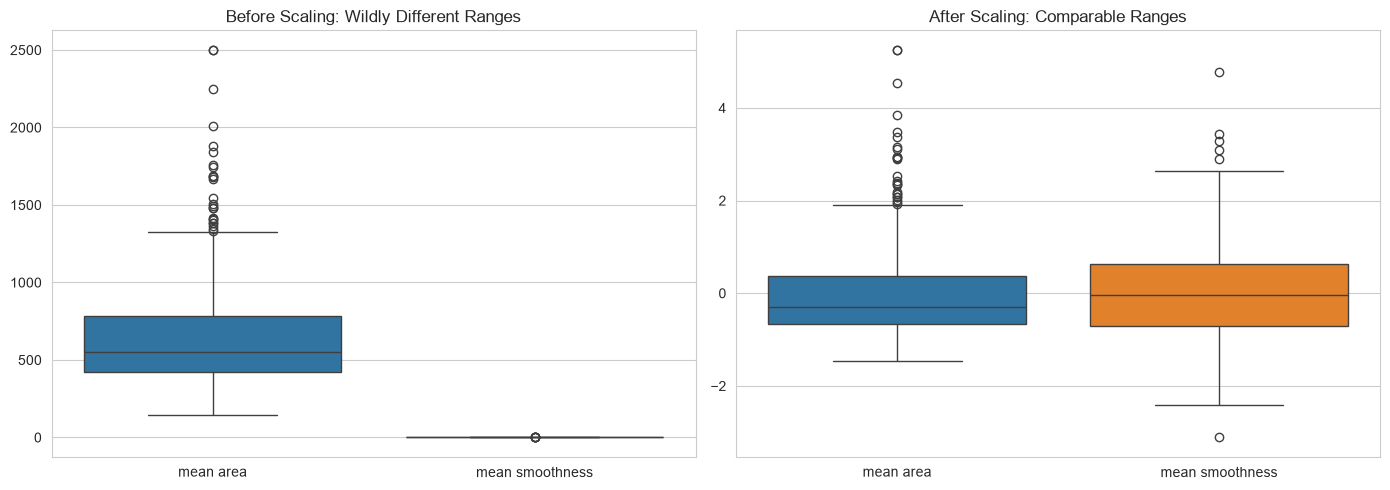

In [12]:
# Compare scale of two features before scaling
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.boxplot(data=df[['mean area', 'mean smoothness']], ax=axes[0])
axes[0].set_title('Before Scaling: Wildly Different Ranges')

scaler_demo = StandardScaler()
demo_scaled = scaler_demo.fit_transform(df[['mean area', 'mean smoothness']])
demo_df = pd.DataFrame(demo_scaled, columns=['mean area', 'mean smoothness'])

sns.boxplot(data=demo_df, ax=axes[1])
axes[1].set_title('After Scaling: Comparable Ranges')

plt.tight_layout()
plt.show()

## Train-Test Split

Before scaling the full dataset, we split into **training** and **testing** sets. 

**Important rule:** We fit the scaler ONLY on training data, then use it to transform 
both train and test data. This prevents **data leakage** — where information from 
the test set accidentally influences training.

In [13]:
X = df.drop('target', axis=1)
y = df['target']

# Split BEFORE scaling to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

# Scale AFTER split
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled = scaler.transform(X_test)          # only transform on test

print("\nScaling complete.")

Training set shape: (455, 30)
Testing set shape: (114, 30)

Scaling complete.


## Baseline KNN Model

Let's start with a simple KNN model using an arbitrary K (K=5, the scikit-learn default) 
just to see how it performs before we optimize anything.

In [14]:
# Baseline model with K=5
knn_baseline = KNeighborsClassifier(n_neighbors=5)
knn_baseline.fit(X_train_scaled, y_train)

y_pred_baseline = knn_baseline.predict(X_test_scaled)

baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
print(f"Baseline KNN (K=5) Accuracy: {baseline_accuracy:.4f}")

Baseline KNN (K=5) Accuracy: 0.9561


## Finding the Optimal K using Cross-Validation

Picking K=5 arbitrarily isn't good practice. Too small a K makes the model sensitive 
to noise (overfitting); too large a K oversmooths the decision boundary and can 
misclassify (underfitting).

We'll use **5-fold Cross-Validation**: split the training data into 5 parts, train on 
4, validate on 1, rotate through all 5 combinations, and average the accuracy. This 
gives a more reliable estimate of performance than a single train-test split.

We'll test K values from 1 to 30 and plot the results to find the sweet spot.

In [15]:
k_range = range(1, 31)
cv_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

# Find the best K
best_k = k_range[cv_scores.index(max(cv_scores))]
print(f"Best K: {best_k}")
print(f"Best Cross-Validated Accuracy: {max(cv_scores):.4f}")

Best K: 8
Best Cross-Validated Accuracy: 0.9714


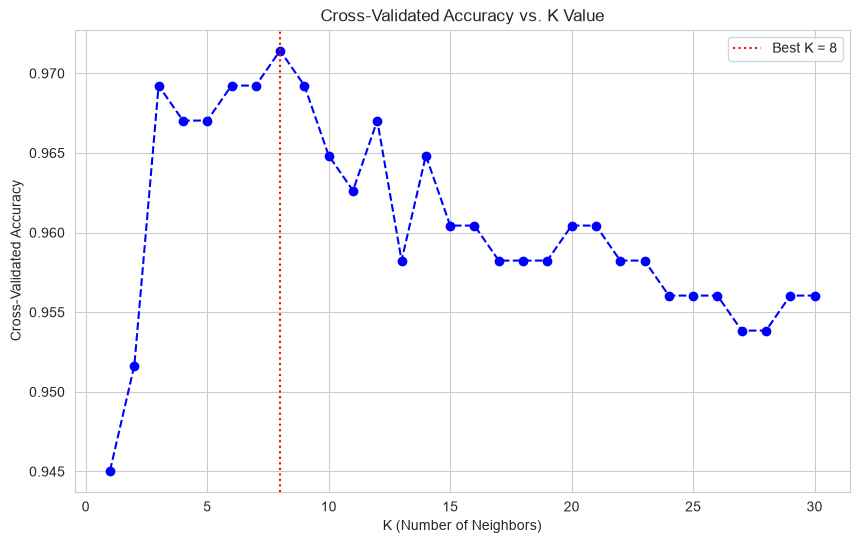

In [16]:
plt.figure(figsize=(10,6))
plt.plot(k_range, cv_scores, marker='o', linestyle='--', color='b')
plt.axvline(best_k, color='red', linestyle=':', label=f'Best K = {best_k}')
plt.title('Cross-Validated Accuracy vs. K Value')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Cross-Validated Accuracy')
plt.legend()
plt.grid(True)
plt.savefig('../images/knn_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

## Training the Final Optimized Model

Now we train our final KNN model using the best K found through cross-validation, 
and evaluate it properly on the **untouched test set**.

In [17]:
# Train final model with best K
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)

y_pred_final = knn_final.predict(X_test_scaled)

final_accuracy = accuracy_score(y_test, y_pred_final)
print(f"Final KNN (K={best_k}) Test Accuracy: {final_accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_final, target_names=data.target_names))

Final KNN (K=8) Test Accuracy: 0.9737

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.95      0.96        42
      benign       0.97      0.99      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



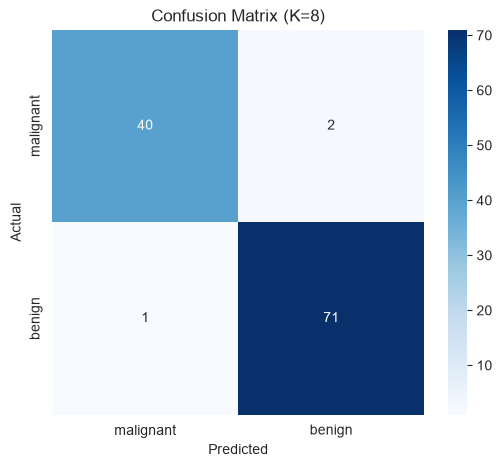

In [18]:
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.title(f'Confusion Matrix (K={best_k})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('../images/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Interpreting the Confusion Matrix

- **True Positives / True Negatives**: Correct predictions.
- **False Positives**: Predicted malignant, actually benign (unnecessary worry/tests).
- **False Negatives**: Predicted benign, actually malignant — the most dangerous 
  error in a medical context, since it means a real cancer case goes undetected.

A good model minimizes false negatives, even if it slightly increases false positives.

## Checking for Overfitting / Underfitting

Before trusting this model, we must check its behavior on both training and testing 
data:

- If **training accuracy is very high** but **testing accuracy is much lower** → 
  **Overfitting** (model memorized training data, doesn't generalize).
- If **both training and testing accuracy are low** → **Underfitting** (model is too 
  simple to capture patterns).
- If **training and testing accuracy are close and both high** → the model 
  **generalizes well**, which is what we want.

In [19]:
train_accuracy = knn_final.score(X_train_scaled, y_train)
test_accuracy = knn_final.score(X_test_scaled, y_test)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy:  {test_accuracy:.4f}")
print(f"Difference:        {abs(train_accuracy - test_accuracy):.4f}")

if train_accuracy - test_accuracy > 0.05:
    print("\n⚠️ Model may be OVERFITTING (large gap between train and test accuracy)")
elif train_accuracy < 0.90 and test_accuracy < 0.90:
    print("\n⚠️ Model may be UNDERFITTING (both accuracies are low)")
else:
    print("\n✅ Model appears to generalize well (train and test accuracy are close)")

Training Accuracy: 0.9758
Testing Accuracy:  0.9737
Difference:        0.0021

✅ Model appears to generalize well (train and test accuracy are close)


## Bias-Variance Tradeoff: Visualizing Train vs Test Accuracy Across K

To fully understand overfitting/underfitting in KNN, let's plot **training accuracy** 
alongside **cross-validated accuracy** across different K values.

- **Small K** (e.g., K=1): Very high training accuracy, but poor generalization → 
  **overfitting**, high variance.
- **Large K**: Training and test accuracy both drop and converge → **underfitting**, 
  high bias.
- **Optimal K**: Where test/cross-validated accuracy peaks — the sweet spot.

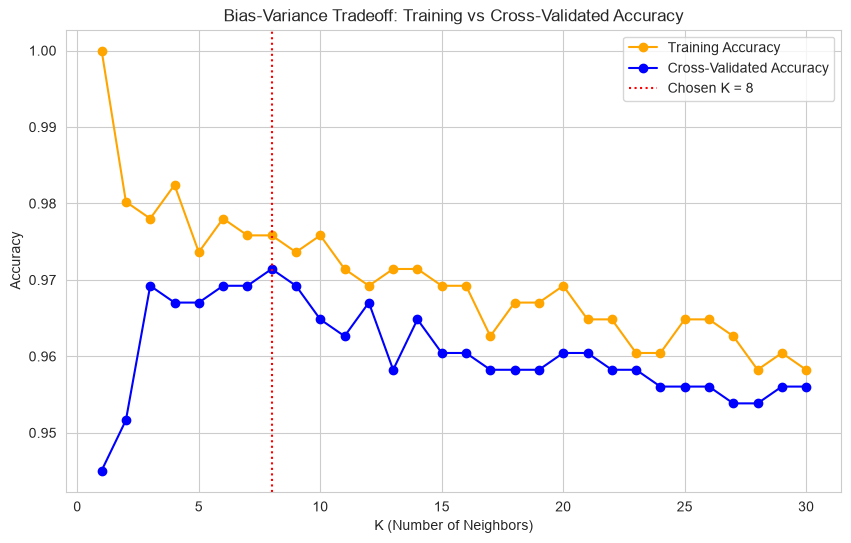

In [20]:
train_scores = []
cv_scores_check = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    train_scores.append(knn.score(X_train_scaled, y_train))
    cv_scores_check.append(cross_val_score(knn, X_train_scaled, y_train, cv=5).mean())

plt.figure(figsize=(10,6))
plt.plot(k_range, train_scores, marker='o', label='Training Accuracy', color='orange')
plt.plot(k_range, cv_scores_check, marker='o', label='Cross-Validated Accuracy', color='blue')
plt.axvline(best_k, color='red', linestyle=':', label=f'Chosen K = {best_k}')
plt.title('Bias-Variance Tradeoff: Training vs Cross-Validated Accuracy')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.savefig('../images/bias_variance_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

## Testing on Completely New, Unseen Data

Let's simulate the real-world scenario: a doctor takes new measurements from a 
patient's cell sample, and we use our trained model to predict whether it's malignant 
or benign. This data was **never touched during training, testing, or cross-validation**.

In [21]:
# Simulate new unseen patient data (using a real sample's values as an example,
# but treating it as brand new incoming data)
import numpy as np

# Example: new patient measurements (30 features, same order as dataset)
new_patient_data = np.array([[
    14.5, 20.3, 95.0, 700.0, 0.1, 0.15, 0.1, 0.07, 0.18, 0.06,
    0.4, 1.2, 3.0, 40.0, 0.006, 0.03, 0.03, 0.015, 0.02, 0.003,
    16.0, 25.0, 110.0, 850.0, 0.14, 0.3, 0.25, 0.12, 0.3, 0.08
]])

# IMPORTANT: Must scale new data using the SAME scaler fitted on training data
new_patient_scaled = scaler.transform(new_patient_data)

prediction = knn_final.predict(new_patient_scaled)
prediction_proba = knn_final.predict_proba(new_patient_scaled)

predicted_class = data.target_names[prediction[0]]
confidence = prediction_proba[0][prediction[0]] * 100

print(f"Predicted Diagnosis: {predicted_class.upper()}")
print(f"Confidence: {confidence:.2f}%")
print(f"\nFull probability breakdown:")
print(f"  Malignant: {prediction_proba[0][0]*100:.2f}%")
print(f"  Benign:    {prediction_proba[0][1]*100:.2f}%")

Predicted Diagnosis: MALIGNANT
Confidence: 62.50%

Full probability breakdown:
  Malignant: 62.50%
  Benign:    37.50%


d:\ML By Campus X\knn-breast-cancer-diagnosis\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## Key Takeaway

By combining **cross-validation** (to select K objectively) with a **train-vs-test 
accuracy check**, we ensured our model neither overfits nor underfits. It generalizes 
well to unseen data — as demonstrated by predicting a diagnosis for a completely new, 
synthetic patient sample.

## Decision Surface Visualization

KNN's decision boundary is easiest to understand visually — but we can only plot 2 
features at a time (or reduce dimensions). We'll do this two ways:

1. Using **2 real features** (mean radius & mean texture) — most interpretable.
2. Using **PCA** to compress all 30 features into 2 components — shows the full 
   picture, but axes lose direct meaning.

The decision surface shows exactly how KNN partitions the feature space into 
regions belonging to each class.

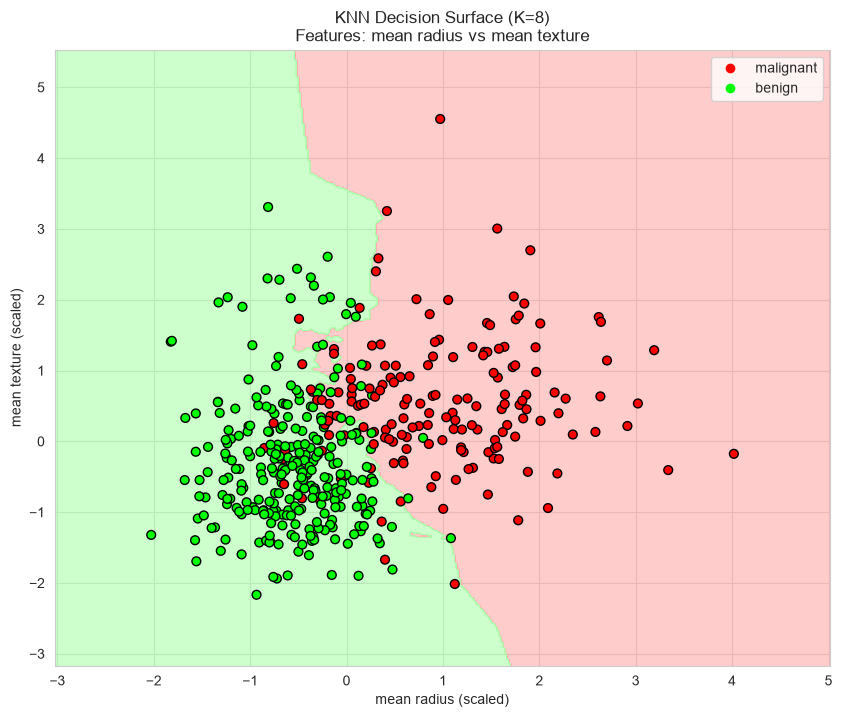

In [22]:
from matplotlib.colors import ListedColormap

# Pick two interpretable features
feature1, feature2 = 'mean radius', 'mean texture'
X_2d = df[[feature1, feature2]].values
y_2d = df['target'].values

# Split and scale just these 2 features
X_2d_train, X_2d_test, y_2d_train, y_2d_test = train_test_split(
    X_2d, y_2d, test_size=0.2, random_state=42, stratify=y_2d
)
scaler_2d = StandardScaler()
X_2d_train_scaled = scaler_2d.fit_transform(X_2d_train)
X_2d_test_scaled = scaler_2d.transform(X_2d_test)

# Train KNN on just these 2 features using the same best_k
knn_2d = KNeighborsClassifier(n_neighbors=best_k)
knn_2d.fit(X_2d_train_scaled, y_2d_train)

# Create a mesh grid covering the feature space
h = 0.02
x_min, x_max = X_2d_train_scaled[:, 0].min() - 1, X_2d_train_scaled[:, 0].max() + 1
y_min, y_max = X_2d_train_scaled[:, 1].min() - 1, X_2d_train_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Predict class for every point in the mesh grid
Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision surface
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00'])

plt.figure(figsize=(10,8))
plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.6)
scatter = plt.scatter(X_2d_train_scaled[:, 0], X_2d_train_scaled[:, 1],
                       c=y_2d_train, cmap=cmap_bold, edgecolor='k', s=40)
plt.xlabel(f'{feature1} (scaled)')
plt.ylabel(f'{feature2} (scaled)')
plt.title(f'KNN Decision Surface (K={best_k})\nFeatures: {feature1} vs {feature2}')
plt.legend(handles=scatter.legend_elements()[0], labels=list(data.target_names))
plt.savefig('../images/decision_surface_2features.png', dpi=150, bbox_inches='tight')
plt.show()

## Decision Surface using PCA (All Features Compressed to 2D)

This gives a more complete picture since it uses information from all 30 features, 
compressed into 2 principal components.

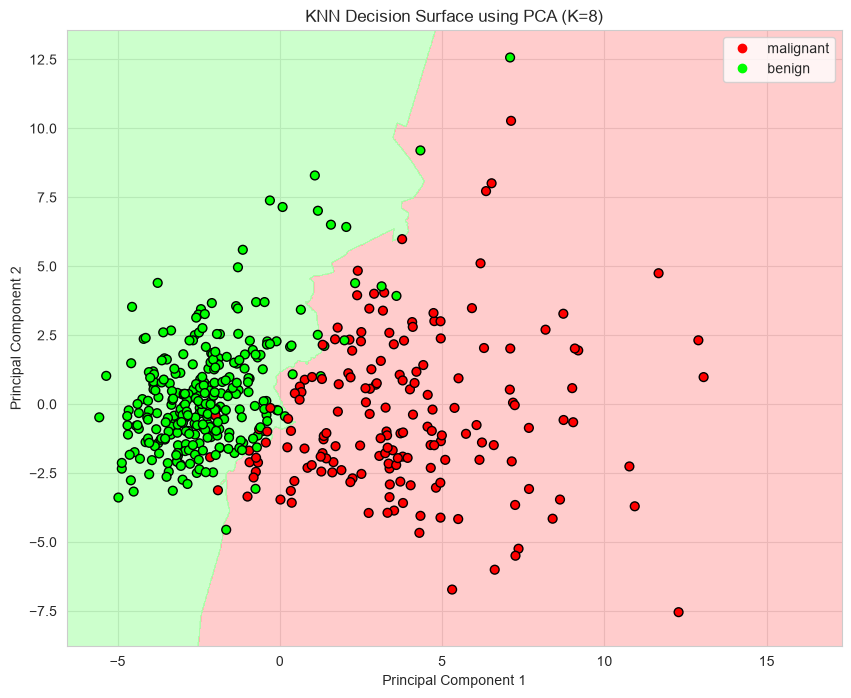

PCA-based model test accuracy: 0.9211


In [24]:
# Reduce all 30 features to 2 principal components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(StandardScaler().fit_transform(X))

X_pca_train, X_pca_test, y_pca_train, y_pca_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y
)

knn_pca = KNeighborsClassifier(n_neighbors=best_k)
knn_pca.fit(X_pca_train, y_pca_train)

# Mesh grid
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = knn_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10,8))
plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.6)
scatter = plt.scatter(X_pca_train[:, 0], X_pca_train[:, 1],
                       c=y_pca_train, cmap=cmap_bold, edgecolor='k', s=40)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title(f'KNN Decision Surface using PCA (K={best_k})')
plt.legend(handles=scatter.legend_elements()[0], labels=list(data.target_names))
plt.savefig('../images/decision_surface_pca.png', dpi=150, bbox_inches='tight')
plt.show()

pca_accuracy = knn_pca.score(X_pca_test, y_pca_test)
print(f"PCA-based model test accuracy: {pca_accuracy:.4f}")

## Saving the Final Model

We save the trained model and the scaler together, since any new data must be 
scaled using the *same* scaler before prediction.

In [25]:
import joblib

joblib.dump(knn_final, '../models/knn_breast_cancer_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

print("Model and scaler saved successfully in the 'models/' folder.")

Model and scaler saved successfully in the 'models/' folder.


In [26]:
# Reload and test to confirm it works exactly like the original
loaded_model = joblib.load('../models/knn_breast_cancer_model.pkl')
loaded_scaler = joblib.load('../models/scaler.pkl')

test_sample_scaled = loaded_scaler.transform(new_patient_data)
test_prediction = loaded_model.predict(test_sample_scaled)

print(f"Reloaded model prediction: {data.target_names[test_prediction[0]]}")
print("Matches original prediction:", data.target_names[test_prediction[0]] == predicted_class)

Reloaded model prediction: malignant
Matches original prediction: True


d:\ML By Campus X\knn-breast-cancer-diagnosis\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
